Importing the Required Libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit.transpiler import PassManager, TransformationPass
from qiskit.dagcircuit import DAGCircuit
from qiskit_aer import AerSimulator

Writing the Custom Pass

In [2]:
class RemoveRedundantGates(TransformationPass):
    def run(self, dag):
        nodes = list(dag.op_nodes())
        i = 0
        while i < len(nodes) - 1:
            node1 = nodes[i]
            node2 = nodes[i + 1]
            if (node1.op.name == node2.op.name and 
                node1.op.name in ['h', 'x', 'y', 'z'] and
                node1.qargs == node2.qargs):
                dag.remove_op_node(node1)
                dag.remove_op_node(node2)
                i += 2
            else:
                i += 1
        return dag

Creating a Test Circuit

Original circuit:


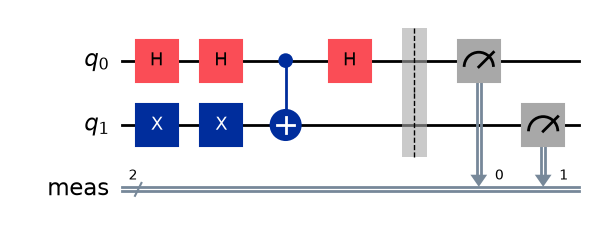

In [6]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(0)          # Redundant: two H gates cancel
qc.x(1)
qc.x(1)          # Redundant: two X gates cancel
qc.cx(0, 1)
qc.h(0)
qc.measure_all()

print("Original circuit:")
qc.draw('mpl')

Applying the Custom Pass

Optimized circuit:


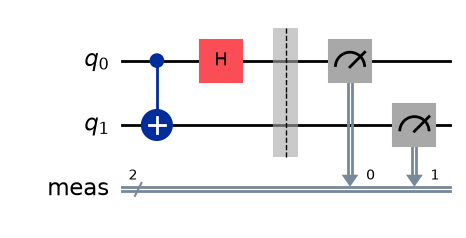

In [7]:
pm = PassManager()
pm.append(RemoveRedundantGates())
optimized_qc = pm.run(qc)

print("Optimized circuit:")
optimized_qc.draw('mpl')

Verifying with Simulation

In [5]:
sim = AerSimulator()

# Transpile both circuits for the simulator
t_qc = qc.copy()
t_opt = optimized_qc.copy()

# Run simulations
result_original = sim.run(t_qc, shots=1024).result()
result_optimized = sim.run(t_opt, shots=1024).result()

counts_original = result_original.get_counts()
counts_optimized = result_optimized.get_counts()

print("Original circuit counts:", counts_original)
print("Optimized circuit counts:", counts_optimized)

Original circuit counts: {'00': 509, '01': 515}
Optimized circuit counts: {'01': 474, '00': 550}
